<a href="https://colab.research.google.com/github/sahitani/Gen-AI-Project/blob/main/dell_dispatch_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1 — Import libraries and set random seed

import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Setting random seed for reproducibility
# This is critical — same seed means same "random" data every time
np.random.seed(42)

print("Libraries imported ✓")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version:  {np.__version__}")

Libraries imported ✓
Pandas version: 2.2.2
NumPy version:  2.0.2


In [2]:
# Cell 2 — Generate 10,000 realistic ticket records

N_RECORDS = 10000

# Helper lists for categorical features
issue_categories = ['Keyboard', 'Battery', 'Screen', 'Fan', 'Storage',
                    'Memory', 'Motherboard', 'Audio', 'Miscellaneous']
device_models = ['Latitude 5420', 'Latitude 7430', 'XPS 13', 'XPS 15',
                 'Precision 3560', 'Inspiron 5510', 'OptiPlex 7090']
warranty_types = ['Basic', 'ProSupport', 'ProSupport Plus']
regions = ['APJ', 'EMEA', 'AMER']

# Generate base data
data = {
    'ticket_id': [f'TKT-{str(i).zfill(6)}' for i in range(1, N_RECORDS + 1)],
    'issue_category': np.random.choice(issue_categories, N_RECORDS),
    'device_model': np.random.choice(device_models, N_RECORDS),
    'device_age_days': np.random.randint(30, 1500, N_RECORDS),
    'warranty_type': np.random.choice(warranty_types, N_RECORDS,
                                       p=[0.3, 0.5, 0.2]),
    'region': np.random.choice(regions, N_RECORDS, p=[0.25, 0.35, 0.40]),

    # Telemetry features — these are the new IoT insights
    'avg_cpu_temp_celsius': np.random.normal(65, 10, N_RECORDS).clip(40, 95),
    'max_cpu_temp_celsius': np.random.normal(82, 8, N_RECORDS).clip(55, 105),
    'battery_cycles': np.random.randint(50, 1200, N_RECORDS),
    'battery_health_pct': np.random.normal(85, 15, N_RECORDS).clip(20, 100),
    'disk_error_count': np.random.poisson(2, N_RECORDS),
    'memory_error_count': np.random.poisson(1, N_RECORDS),
    'boot_failure_count': np.random.poisson(0.5, N_RECORDS),
    'thermal_throttle_events': np.random.poisson(3, N_RECORDS),
    'avg_daily_uptime_hours': np.random.normal(8, 3, N_RECORDS).clip(1, 16),

    # Customer history
    'previous_ticket_count': np.random.poisson(2, N_RECORDS),
    'previous_false_dispatch_count': np.random.poisson(0.3, N_RECORDS),
    'days_since_last_ticket': np.random.randint(0, 365, N_RECORDS),

    # Agent interaction
    'customer_self_diagnosed': np.random.choice([0, 1], N_RECORDS,
                                                 p=[0.7, 0.3]),
    'symptom_severity_reported': np.random.randint(1, 6, N_RECORDS)
}

# Convert to DataFrame
df = pd.DataFrame(data)

print(f"Dataset created with {len(df)} rows and {len(df.columns)} columns")
print(f"\nFirst 3 rows:")
print(df.head(3))

Dataset created with 10000 rows and 20 columns

First 3 rows:
    ticket_id issue_category   device_model  device_age_days warranty_type  \
0  TKT-000001    Motherboard  Inspiron 5510              958         Basic   
1  TKT-000002            Fan         XPS 15              877    ProSupport   
2  TKT-000003          Audio         XPS 13              897    ProSupport   

  region  avg_cpu_temp_celsius  max_cpu_temp_celsius  battery_cycles  \
0   EMEA             59.971691             77.352436             762   
1   AMER             56.145344             75.661358             750   
2    APJ             67.718591             81.598918             940   

   battery_health_pct  disk_error_count  memory_error_count  \
0           84.067551                 0                   0   
1           59.210908                 3                   3   
2           85.825031                 1                   1   

   boot_failure_count  thermal_throttle_events  avg_daily_uptime_hours  \
0        

In [3]:
# Cell 3 — Generate the target label using business logic

# Initialise dispatch probability score for each row
dispatch_score = np.zeros(N_RECORDS)

# ============================================================
# FACTORS INCREASING TRUE DISPATCH LIKELIHOOD (hardware broken)
# ============================================================

# Telemetry degradation signals
dispatch_score += (df['max_cpu_temp_celsius'] - 80) * 0.05
dispatch_score += df['disk_error_count'] * 0.3
dispatch_score += df['memory_error_count'] * 0.4
dispatch_score += df['boot_failure_count'] * 0.5
dispatch_score += df['thermal_throttle_events'] * 0.1

# Device wear
dispatch_score += (df['battery_cycles'] / 500) * 0.4
dispatch_score += ((100 - df['battery_health_pct']) / 100) * 1.2

# Customer-reported severity
dispatch_score += (df['symptom_severity_reported'] - 3) * 0.4

# Device age
dispatch_score += (df['device_age_days'] / 1000) * 0.3

# ============================================================
# FACTORS DECREASING TRUE DISPATCH LIKELIHOOD (false alarm)
# ============================================================

# Customer self-diagnosis is often wrong
dispatch_score -= df['customer_self_diagnosed'] * 0.6

# Customer history of false dispatches
dispatch_score -= df['previous_false_dispatch_count'] * 0.5

# Add realistic noise — real life has randomness
noise = np.random.normal(0, 0.8, N_RECORDS)
dispatch_score += noise

# ============================================================
# CONVERT SCORE TO BINARY LABEL
# ============================================================

# Use threshold to create 80/20 split (realistic class imbalance)
threshold = np.percentile(dispatch_score, 20)

df['dispatch_outcome'] = np.where(dispatch_score > threshold,
                                   'TRUE_DISPATCH',
                                   'FALSE_DISPATCH')

# Check the distribution
print("Label distribution:")
print(df['dispatch_outcome'].value_counts())
print(f"\nFalse dispatch rate: {(df['dispatch_outcome'] == 'FALSE_DISPATCH').mean() * 100:.1f}%")

Label distribution:
dispatch_outcome
TRUE_DISPATCH     8000
FALSE_DISPATCH    2000
Name: count, dtype: int64

False dispatch rate: 20.0%


In [4]:
# Cell 4 — Introduce missing values and save dataset

# Simulate missing telemetry for ~5% of records (older devices)
missing_telemetry_indices = np.random.choice(
    df.index,
    size=int(N_RECORDS * 0.05),
    replace=False
)

telemetry_columns = ['avg_cpu_temp_celsius', 'max_cpu_temp_celsius',
                     'battery_cycles', 'battery_health_pct',
                     'disk_error_count', 'memory_error_count',
                     'boot_failure_count', 'thermal_throttle_events']

df.loc[missing_telemetry_indices, telemetry_columns] = np.nan

# Show missing value summary
print("Missing values per column:")
missing_summary = df.isnull().sum()
print(missing_summary[missing_summary > 0])

# Save to CSV
df.to_csv('dell_dispatch_data.csv', index=False)

print(f"\nDataset saved as dell_dispatch_data.csv")
print(f"Total rows:    {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"\nFinal dataset preview:")
print(df.head(3))

Missing values per column:
avg_cpu_temp_celsius       500
max_cpu_temp_celsius       500
battery_cycles             500
battery_health_pct         500
disk_error_count           500
memory_error_count         500
boot_failure_count         500
thermal_throttle_events    500
dtype: int64

Dataset saved as dell_dispatch_data.csv
Total rows:    10000
Total columns: 21

Final dataset preview:
    ticket_id issue_category   device_model  device_age_days warranty_type  \
0  TKT-000001    Motherboard  Inspiron 5510              958         Basic   
1  TKT-000002            Fan         XPS 15              877    ProSupport   
2  TKT-000003          Audio         XPS 13              897    ProSupport   

  region  avg_cpu_temp_celsius  max_cpu_temp_celsius  battery_cycles  \
0   EMEA             59.971691             77.352436           762.0   
1   AMER             56.145344             75.661358           750.0   
2    APJ             67.718591             81.598918           940.0   

   bat

In [5]:
# Cell 5 — Basic dataset inspection

print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)
print(f"Rows:    {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\n" + "=" * 60)
print("COLUMN TYPES")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_summary[missing_summary['Missing Count'] > 0])

print("\n" + "=" * 60)
print("NUMERIC FEATURES — SUMMARY STATISTICS")
print("=" * 60)
print(df.describe().round(2))

DATASET SHAPE
Rows:    10,000
Columns: 21

COLUMN TYPES
ticket_id                         object
issue_category                    object
device_model                      object
device_age_days                    int64
warranty_type                     object
region                            object
avg_cpu_temp_celsius             float64
max_cpu_temp_celsius             float64
battery_cycles                   float64
battery_health_pct               float64
disk_error_count                 float64
memory_error_count               float64
boot_failure_count               float64
thermal_throttle_events          float64
avg_daily_uptime_hours           float64
previous_ticket_count              int64
previous_false_dispatch_count      int64
days_since_last_ticket             int64
customer_self_diagnosed            int64
symptom_severity_reported          int64
dispatch_outcome                  object
dtype: object

MISSING VALUES
                         Missing Count  Missing %
avg

In [6]:
# Cell 6 — Target Variable Deep Dive

print("=" * 60)
print("OVERALL DISPATCH OUTCOME DISTRIBUTION")
print("=" * 60)
print(df['dispatch_outcome'].value_counts())
print(f"\nFalse Dispatch Rate: {(df['dispatch_outcome'] == 'FALSE_DISPATCH').mean() * 100:.1f}%")

print("\n" + "=" * 60)
print("FALSE DISPATCH RATE BY REGION")
print("=" * 60)
region_dispatch = df.groupby('region')['dispatch_outcome'].apply(
    lambda x: (x == 'FALSE_DISPATCH').mean() * 100
).round(2)
print(region_dispatch)

print("\n" + "=" * 60)
print("FALSE DISPATCH RATE BY ISSUE CATEGORY")
print("=" * 60)
issue_dispatch = df.groupby('issue_category')['dispatch_outcome'].apply(
    lambda x: (x == 'FALSE_DISPATCH').mean() * 100
).round(2).sort_values(ascending=False)
print(issue_dispatch)

print("\n" + "=" * 60)
print("FALSE DISPATCH RATE BY WARRANTY TYPE")
print("=" * 60)
warranty_dispatch = df.groupby('warranty_type')['dispatch_outcome'].apply(
    lambda x: (x == 'FALSE_DISPATCH').mean() * 100
).round(2)
print(warranty_dispatch)

print("\n" + "=" * 60)
print("FALSE DISPATCH RATE BY CUSTOMER SELF-DIAGNOSIS")
print("=" * 60)
selfdiag_dispatch = df.groupby('customer_self_diagnosed')['dispatch_outcome'].apply(
    lambda x: (x == 'FALSE_DISPATCH').mean() * 100
).round(2)
print(selfdiag_dispatch)

OVERALL DISPATCH OUTCOME DISTRIBUTION
dispatch_outcome
TRUE_DISPATCH     8000
FALSE_DISPATCH    2000
Name: count, dtype: int64

False Dispatch Rate: 20.0%

FALSE DISPATCH RATE BY REGION
region
AMER    20.23
APJ     19.95
EMEA    19.77
Name: dispatch_outcome, dtype: float64

FALSE DISPATCH RATE BY ISSUE CATEGORY
issue_category
Miscellaneous    21.61
Keyboard         21.53
Fan              20.46
Screen           20.20
Audio            20.13
Motherboard      19.75
Storage          19.29
Memory           18.53
Battery          18.43
Name: dispatch_outcome, dtype: float64

FALSE DISPATCH RATE BY WARRANTY TYPE
warranty_type
Basic              21.0
ProSupport         19.6
ProSupport Plus    19.5
Name: dispatch_outcome, dtype: float64

FALSE DISPATCH RATE BY CUSTOMER SELF-DIAGNOSIS
customer_self_diagnosed
0    16.31
1    28.58
Name: dispatch_outcome, dtype: float64


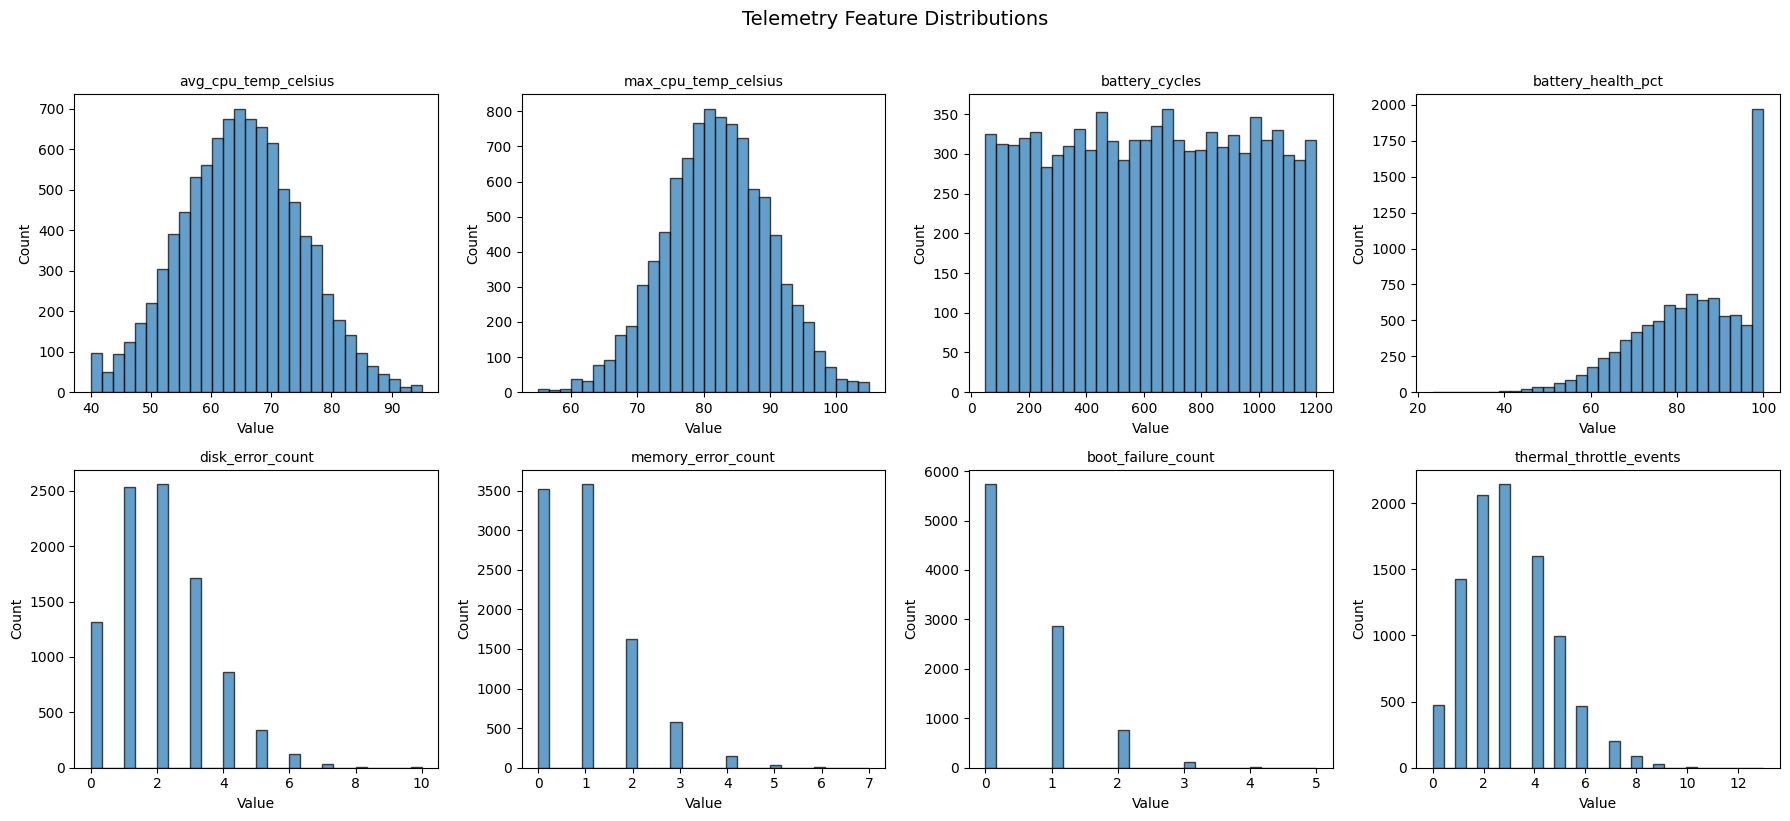

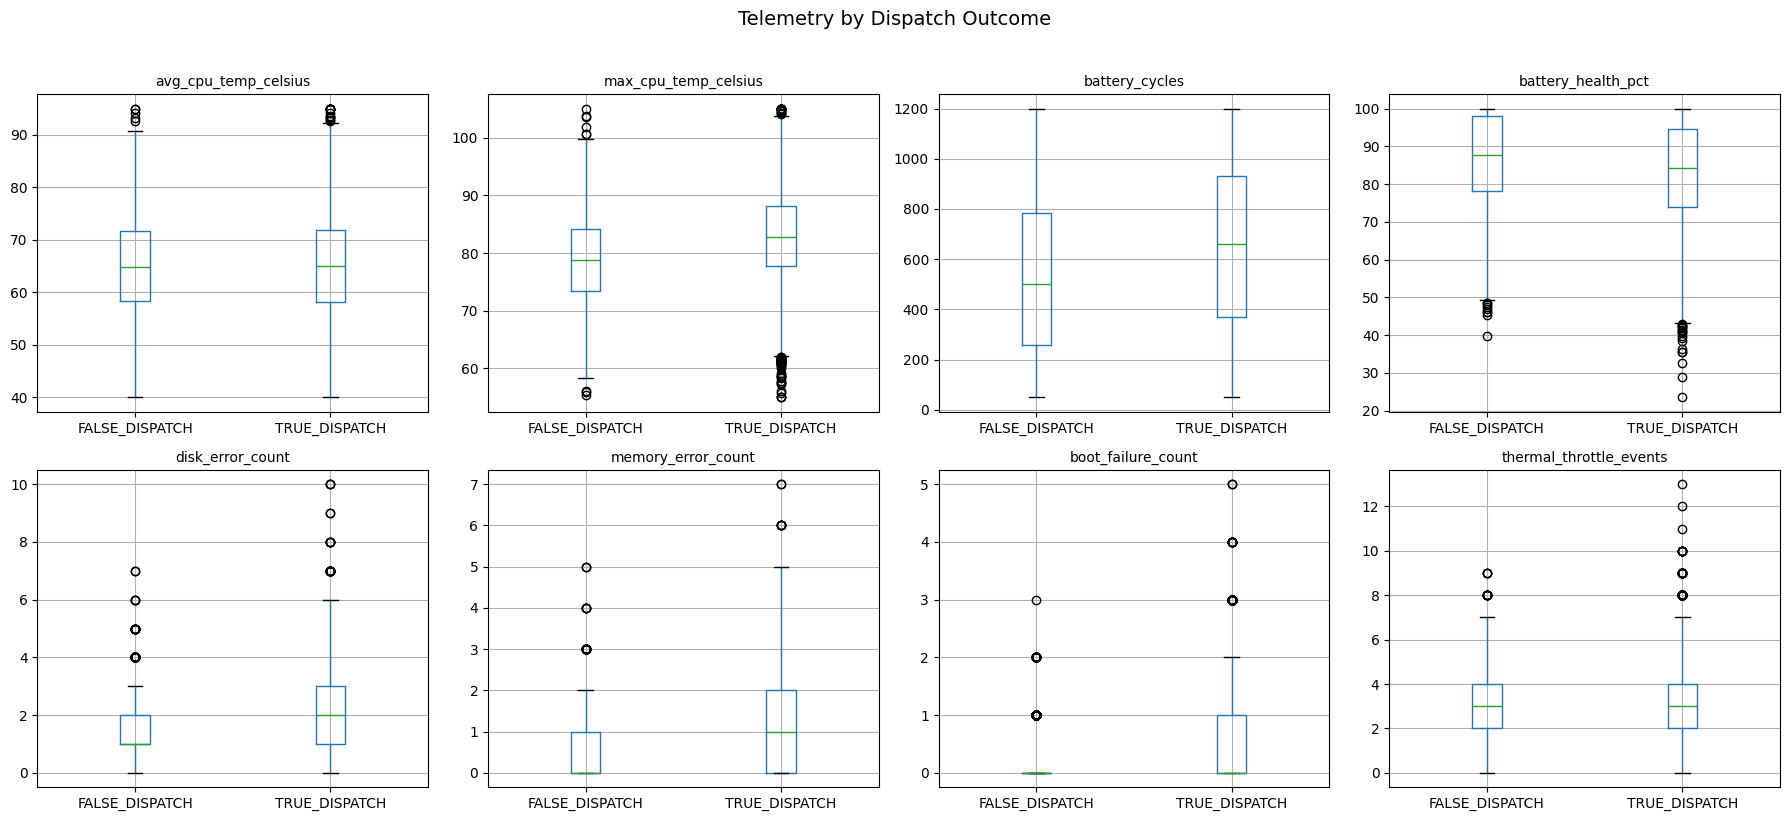

In [7]:
# Cell 7 — Visual distribution analysis

import matplotlib.pyplot as plt
import seaborn as sns

# Telemetry features we want to visualise
telemetry_features = ['avg_cpu_temp_celsius', 'max_cpu_temp_celsius',
                      'battery_cycles', 'battery_health_pct',
                      'disk_error_count', 'memory_error_count',
                      'boot_failure_count', 'thermal_throttle_events']

# Create 2 rows x 4 columns grid of histograms
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feature in enumerate(telemetry_features):
    axes[i].hist(df[feature].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(feature, fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Telemetry Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Now box plots split by dispatch outcome
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feature in enumerate(telemetry_features):
    df.boxplot(column=feature, by='dispatch_outcome', ax=axes[i])
    axes[i].set_title(feature, fontsize=10)
    axes[i].set_xlabel('')

plt.suptitle('Telemetry by Dispatch Outcome', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

FEATURE CORRELATION WITH TARGET (TRUE_DISPATCH)
symptom_severity_reported        0.302
max_cpu_temp_celsius             0.205
disk_error_count                 0.198
memory_error_count               0.177
boot_failure_count               0.169
battery_cycles                   0.133
thermal_throttle_events          0.095
device_age_days                  0.077
days_since_last_ticket           0.010
avg_cpu_temp_celsius            -0.000
previous_ticket_count           -0.001
avg_daily_uptime_hours          -0.004
battery_health_pct              -0.095
customer_self_diagnosed         -0.141
previous_false_dispatch_count   -0.162
Name: target_numeric, dtype: float64

HIGH CORRELATIONS BETWEEN FEATURES (>|0.3|)
No feature pairs with correlation above 0.3


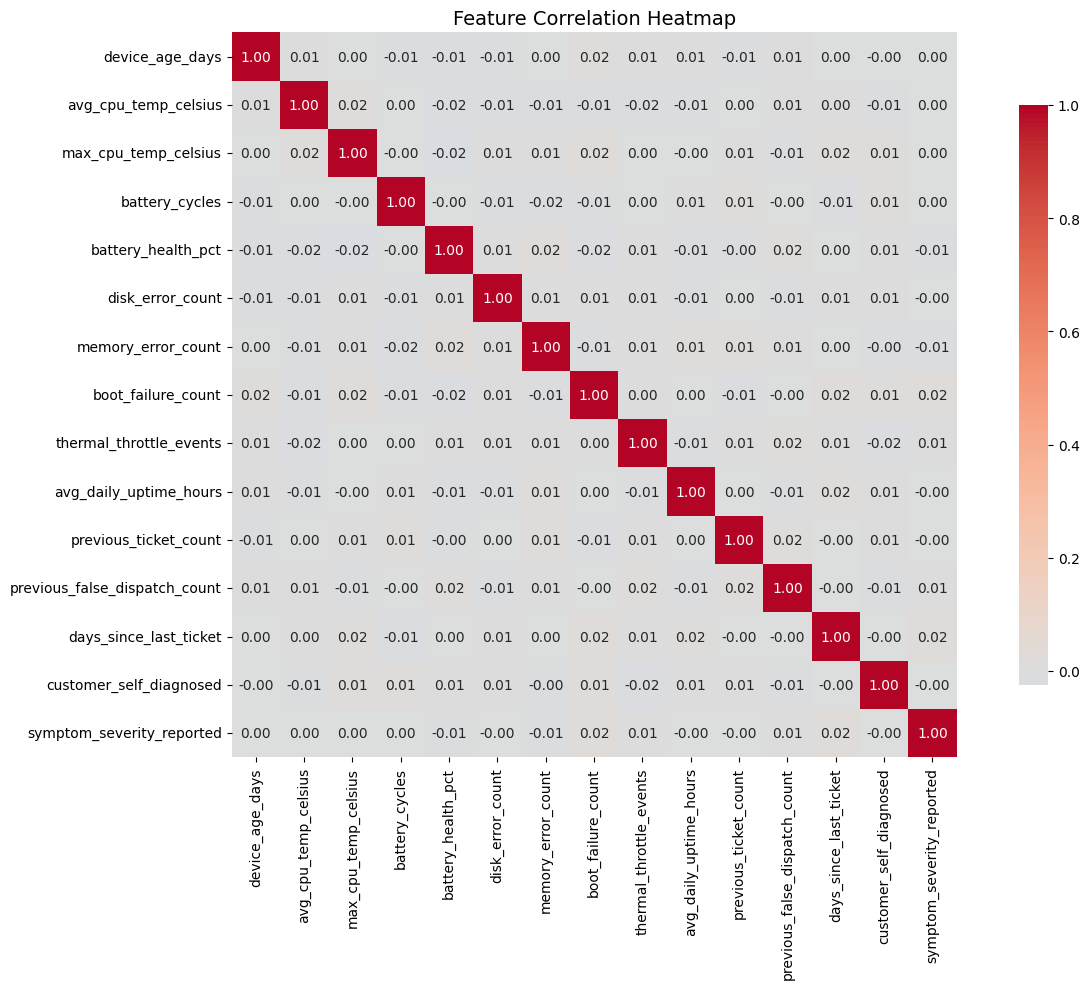

In [8]:
# Cell 8 — Correlation Analysis

# Convert label to numeric for correlation calculation
df['target_numeric'] = (df['dispatch_outcome'] == 'TRUE_DISPATCH').astype(int)

# Select numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('target_numeric')  # remove from features list

# Calculate correlations of each feature with the target
print("=" * 60)
print("FEATURE CORRELATION WITH TARGET (TRUE_DISPATCH)")
print("=" * 60)

target_correlations = df[numeric_cols + ['target_numeric']].corr()['target_numeric']
target_correlations = target_correlations.drop('target_numeric').sort_values(ascending=False)
print(target_correlations.round(3))

# Now check correlations BETWEEN features (multicollinearity check)
print("\n" + "=" * 60)
print("HIGH CORRELATIONS BETWEEN FEATURES (>|0.3|)")
print("=" * 60)

corr_matrix = df[numeric_cols].corr()

# Find pairs with high correlation
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.3:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': round(corr_value, 3)
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation',
                                                               key=abs,
                                                               ascending=False)
    print(high_corr_df.to_string(index=False))
else:
    print("No feature pairs with correlation above 0.3")

# Visualise correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# Drop the temporary numeric target column
df = df.drop('target_numeric', axis=1)